In [1]:
import nltk
nltk.download("movie_reviews")
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("punkt_tab")

from nltk.corpus import movie_reviews

[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [2]:
print(len(movie_reviews.fileids()))
print(movie_reviews.fileids()[:5])

negative_fileids = movie_reviews.fileids('neg')
positive_fileids = movie_reviews.fileids('pos')

print(len(negative_fileids), len(positive_fileids))


2000
['neg/cv000_29416.txt', 'neg/cv001_19502.txt', 'neg/cv002_17424.txt', 'neg/cv003_12683.txt', 'neg/cv004_12641.txt']
1000 1000


In [3]:
print(movie_reviews.raw(fileids=positive_fileids[0]))

films adapted from comic books have had plenty of success , whether they're about superheroes ( batman , superman , spawn ) , or geared toward kids ( casper ) or the arthouse crowd ( ghost world ) , but there's never really been a comic book like from hell before . 
for starters , it was created by alan moore ( and eddie campbell ) , who brought the medium to a whole new level in the mid '80s with a 12-part series called the watchmen . 
to say moore and campbell thoroughly researched the subject of jack the ripper would be like saying michael jackson is starting to look a little odd . 
the book ( or " graphic novel , " if you will ) is over 500 pages long and includes nearly 30 more that consist of nothing but footnotes . 
in other words , don't dismiss this film because of its source . 
if you can get past the whole comic book thing , you might find another stumbling block in from hell's directors , albert and allen hughes . 
getting the hughes brothers to direct this seems almost as 

In [4]:
romeo_text = """Why then, O brawling love! O loving hate!
O any thing, of nothing first create!
O heavy lightness, serious vanity,
Misshapen chaos of well-seeming forms,
Feather of lead, bright smoke, cold fire, sick health,
Still-waking sleep, that is not what it is!
This love feel I, that feel no love in this."""

romeo_words = nltk.word_tokenize(romeo_text)
romeo_words[:15]


['Why',
 'then',
 ',',
 'O',
 'brawling',
 'love',
 '!',
 'O',
 'loving',
 'hate',
 '!',
 'O',
 'any',
 'thing',
 ',']

In [5]:
def build_bag_of_words_features(words):
    return {word: True for word in words}

build_bag_of_words_features(romeo_words)


{'Why': True,
 'then': True,
 ',': True,
 'O': True,
 'brawling': True,
 'love': True,
 '!': True,
 'loving': True,
 'hate': True,
 'any': True,
 'thing': True,
 'of': True,
 'nothing': True,
 'first': True,
 'create': True,
 'heavy': True,
 'lightness': True,
 'serious': True,
 'vanity': True,
 'Misshapen': True,
 'chaos': True,
 'well-seeming': True,
 'forms': True,
 'Feather': True,
 'lead': True,
 'bright': True,
 'smoke': True,
 'cold': True,
 'fire': True,
 'sick': True,
 'health': True,
 'Still-waking': True,
 'sleep': True,
 'that': True,
 'is': True,
 'not': True,
 'what': True,
 'it': True,
 'This': True,
 'feel': True,
 'I': True,
 'no': True,
 'in': True,
 'this': True,
 '.': True}

In [6]:
import string
useless_words = nltk.corpus.stopwords.words("english") + list(string.punctuation)

def build_bag_of_words_features_filtered(words):
    return {word: True for word in words if word not in useless_words}

build_bag_of_words_features_filtered(romeo_words)


{'Why': True,
 'O': True,
 'brawling': True,
 'love': True,
 'loving': True,
 'hate': True,
 'thing': True,
 'nothing': True,
 'first': True,
 'create': True,
 'heavy': True,
 'lightness': True,
 'serious': True,
 'vanity': True,
 'Misshapen': True,
 'chaos': True,
 'well-seeming': True,
 'forms': True,
 'Feather': True,
 'lead': True,
 'bright': True,
 'smoke': True,
 'cold': True,
 'fire': True,
 'sick': True,
 'health': True,
 'Still-waking': True,
 'sleep': True,
 'This': True,
 'feel': True,
 'I': True}

[('film', 9517), ('one', 5852), ('movie', 5771), ('like', 3690), ('even', 2565), ('good', 2411), ('time', 2411), ('story', 2169), ('would', 2109), ('much', 2049)]


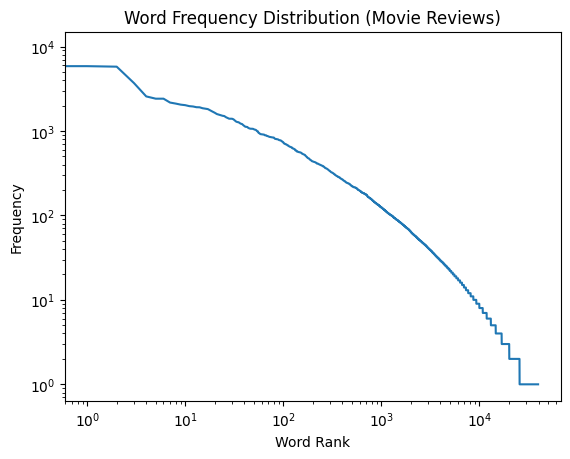

In [7]:
from collections import Counter
import matplotlib.pyplot as plt

filtered_words = [word for word in movie_reviews.words() if word not in useless_words]
word_counter = Counter(filtered_words)

most_common_words = word_counter.most_common(10)
print(most_common_words)

sorted_word_counts = sorted(list(word_counter.values()), reverse=True)

plt.loglog(sorted_word_counts)
plt.ylabel("Frequency")
plt.xlabel("Word Rank")
plt.title("Word Frequency Distribution (Movie Reviews)")
plt.show()


In [8]:
negative_features = [
    (build_bag_of_words_features_filtered(movie_reviews.words(fileids=[f])), 'neg')
    for f in negative_fileids
]

positive_features = [
    (build_bag_of_words_features_filtered(movie_reviews.words(fileids=[f])), 'pos')
    for f in positive_fileids
]

split = 800
train_set = positive_features[:split] + negative_features[:split]
test_set = positive_features[split:] + negative_features[split:]

from nltk.classify import NaiveBayesClassifier
sentiment_classifier = NaiveBayesClassifier.train(train_set)


In [9]:
train_accuracy = nltk.classify.util.accuracy(sentiment_classifier, train_set) * 100
test_accuracy = nltk.classify.util.accuracy(sentiment_classifier, test_set) * 100

print(f"Training Accuracy: {train_accuracy:.2f}%")
print(f"Testing Accuracy: {test_accuracy:.2f}%")

sentiment_classifier.show_most_informative_features(10)


Training Accuracy: 98.06%
Testing Accuracy: 71.75%
Most Informative Features
             outstanding = True              pos : neg    =     13.9 : 1.0
               insulting = True              neg : pos    =     13.7 : 1.0
              vulnerable = True              pos : neg    =     13.0 : 1.0
               ludicrous = True              neg : pos    =     12.6 : 1.0
             uninvolving = True              neg : pos    =     12.3 : 1.0
              astounding = True              pos : neg    =     11.7 : 1.0
                  avoids = True              pos : neg    =     11.7 : 1.0
             fascination = True              pos : neg    =     11.0 : 1.0
               affecting = True              pos : neg    =     10.3 : 1.0
               animators = True              pos : neg    =     10.3 : 1.0
